This notebook is inspired by the following sources:
- https://agussudjianto.substack.com/p/the-geometry-of-a-crash-why-market
- https://www.youtube.com/watch?v=VTlrVSJfvH4

In [1]:
import os
os.chdir('..')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.data_io import YahooFinance

# Download Data

In [3]:
tickers = ['SPY', 'XLK', 'XLF', 'XLV', 'XLE', 'XLI', 'XLY', 'XLP', 'XLB', 'XLU']
start_date = '2000-01-01'
end_date = '2026-03-01'

dfs = [YahooFinance(ticker, start_date, end_date).pipeline() for ticker in tickers]

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [4]:
dfs[0].head()

,date,adj_close,log_return
0,2000-01-03,91.367531,NaN
1,2000-01-04,87.794464,-0.039892
2,2000-01-05,87.951515,0.001787
3,2000-01-06,86.538033,-0.016202
4,2000-01-07,91.563866,0.056453


In [5]:
def create_df(dfs:list[pd.DataFrame], tickers:list[str]):
    df = dfs[0][['date', 'log_return']].copy()
    df.columns = ['date', tickers[0]]
    
    for i in range(1, len(dfs)):
        temp_df = dfs[i][['date', 'log_return']].copy()
        temp_df.columns = ['date', tickers[i]]
        df = df.merge(temp_df, on='date', how='inner')
    
    df.set_index('date', inplace=True)
    return df

df = create_df(dfs, tickers).dropna()
df.head(5)

,SPY,XLK,XLF,XLV,XLE,XLI,XLY,XLP,XLB,XLU
date,,,,,,,,,,
2000-01-04,-0.039892,-0.052065,-0.044700,-0.022954,-0.019003,-0.028017,-0.030545,-0.028564,-0.009674,-0.030629
2000-01-05,0.001787,-0.014957,-0.007888,-0.009011,0.026036,-0.004466,-0.012376,0.017514,0.040482,0.024922
2000-01-06,-0.016202,-0.033715,0.042979,0.003189,0.037827,0.013341,0.011305,0.018576,0.025346,-0.001718
2000-01-07,0.056453,0.017306,0.016417,0.012134,0.010630,0.037393,0.046033,0.061466,-0.000568,0.008564
2000-01-10,0.003425,0.037286,-0.017797,0.097358,-0.008383,0.000000,-0.005125,-0.022692,-0.003421,0.003405


# About Wedge Volume

The wedge product a ∧ b measures the oriented area swept out by two vectors. In three dimensions the wedge product generalises naturally. The wedge product of three vectors a ∧ b ∧ c measures the oriented volume of the parallelepiped they span.

Before we dive into the Wedge Volume, lets first recall the Covariance Matrix:
- $Cov[x, y] = \frac{1}{n}\sum(x-\bar{x})(y-\bar{y})$

This is equivalent to the demeaned dot product of two vectors:
- $Cov[x, y] = \frac{1}{n}(\vec{a} \cdot \vec{b})$

## Gram Matrix
A Gram matrix (or Gramian matrix) is a square matrix that records the pairwise inner products (or dot products) of a set of vectors. If we demean the vectors, we get a covariance matrix:
$$G = X^TX$$
$$G = nCov[X_i, X_j]$$

However, we have the option to keep the first central moment or the drift in our case to preserve direction.

Next, we recall the Correlation formula:
- $Corr(x, y) = \frac{Cov[x, y]}{\sigma_x\sigma_y}$

By normalizing the second central moment, we strip away the scale and focus on the co-movement between assets after accounting for shared drift by subtracting away the first central moment.

Similarly, we will normalize the Gram matrix by the L2 norm to get unit vectors. Note that we have not removed the first central moment and have successfully kept the directional information of our vectors.

## Connecting the Ideas
Lastly, we can connect the two ideas of the Wedge Volume and the Gram Matrix. Imagine a 2x2 matrix, we have the following equations:
$$|a ∧ b|² = |a|²|b|² − (a \cdot b)²$$
$$G = X^TX$$
$$
G = \begin{pmatrix}
a \cdot a & a \cdot b \\
b \cdot a & b \cdot b
\end{pmatrix}
$$
$$det(G) = (a \cdot a)(b \cdot b) - (a \cdot b)^2$$

Therefore, based on the first and last line, the next line follows naturally:
$$|a ∧ b|² = det(G)$$
$$|a ∧ b| = \sqrt{det(G)}$$

Recall that the wedge product is either the area or the volume of the interested vectors, this implies:
- When the Wedge Volume is 0, all vectors collapse on the same plane and we are likely experiencing a market crash.
- When the Wedge Volume is 1, all vectors are orthogonal to each other and we have perfect diversification.

But why use this over an expected pairwise correlation using a rolling window? The beauty of the Wedge Volume is when we have a basket of assets where a certain pair of asset suddenly has perfect correlation. However, this would not be updated using the rolling average correlation due to the vast number of pairs that dilute the metric. The Wedge Volume captures volume, and when a pair of assets collapse onto the same plane, the total volume decreases significantly and we would see it on the chart.

In [6]:
def wedge_volume(df:pd.DataFrame, window_size:int=60):
    """
    Calculate the wedge volume using the Gram matrix approach. Assumes window_data is a 2D array where rows are time points and columns are assets.
    Note that we take the absolute value of the determinant to ensure we get a non-negative volume, 
    as numerical issues can sometimes lead to a slightly negative determinant for a positive semidefinite matrix.
    
    Volume = 0 means linear dependence (Crisis mode) while volume = 1 means orthogonality (Perfect Diversification).
    """
    wedge_volumes = []
    data = df.values
    total_len = len(data)
    for i in range(window_size, total_len):
        window_data = data[i-window_size:i]
        
        # Normalize vectors to isolate direction from magnitude
        norms = np.linalg.norm(window_data, axis=0)
        norms[norms == 0] = 1e-8 # Prevent divide-by-zero
        normalized_window = window_data / norms
        
        # Calculate the Gram matrix and the wedge volume
        gram_mat = normalized_window.T @ normalized_window
        det = np.linalg.det(gram_mat)
        wedge_volume = np.sqrt(np.abs(det)) # Absolute to ensure non-negativity due to numerical issues
        wedge_volumes.append(wedge_volume)
    
    result = np.full(total_len, np.nan)
    result[window_size:] = wedge_volumes
    result = pd.Series(result, index=df.index)
    return result

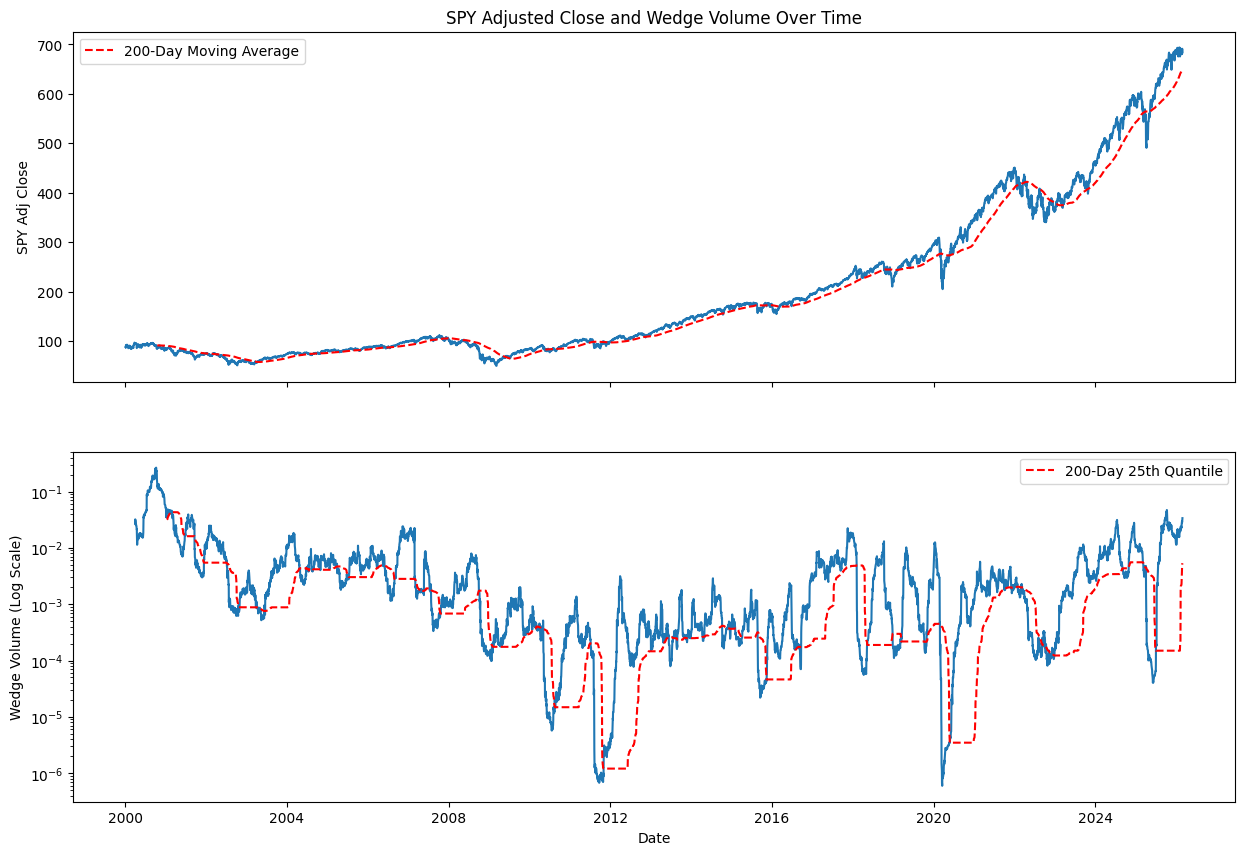

In [7]:
wedge_vol_series = wedge_volume(df)
fig, axes= plt.subplots(nrows=2, ncols=1, figsize=(15, 10), sharex=True)

spy_data = dfs[0].copy()
spy_data.set_index('date', inplace=True)
spy_200_sma = spy_data['adj_close'].rolling(window=200).mean()
rolling_ma = spy_200_sma.loc[df.index] # Align with wedge volume index
spy_data = spy_data.loc[df.index] # Align with wedge volume index

axes[0].set_title('SPY Adjusted Close and Wedge Volume Over Time')
axes[0].plot(spy_data['adj_close'])
axes[0].plot(rolling_ma, color='red', linestyle='--', label='200-Day Moving Average')
axes[0].set_ylabel('SPY Adj Close')
axes[0].legend()

wedge_vol_sma = wedge_vol_series.rolling(window=200).quantile(0.25)
axes[1].plot(wedge_vol_series)
axes[1].plot(wedge_vol_sma, color='red', linestyle='--', label='200-Day 25th Quantile')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Wedge Volume (Log Scale)')
axes[1].set_yscale('log')
axes[1].legend()
plt.show()

A potential idea to explore is using the Wedge Volume as a signal for cyclical sectors. If a tide lifts all boats, then the Wedge Volume should drop significantly during the start of an upcycle. Naturally, this can also occur during the downcycle. Hence, the challenge is defining the threshold and finding a directional measure.

In [8]:
uranium_us_tickers = ["URA", "CCJ", "UEC", "DNN", "UUUU", "LEU"]
start_date = '2000-01-01'
end_date = '2026-03-01'
dfs = [YahooFinance(ticker, start_date, end_date).pipeline() for ticker in uranium_us_tickers]
df = create_df(dfs, uranium_us_tickers).dropna()
wedge_vol_series = wedge_volume(df)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


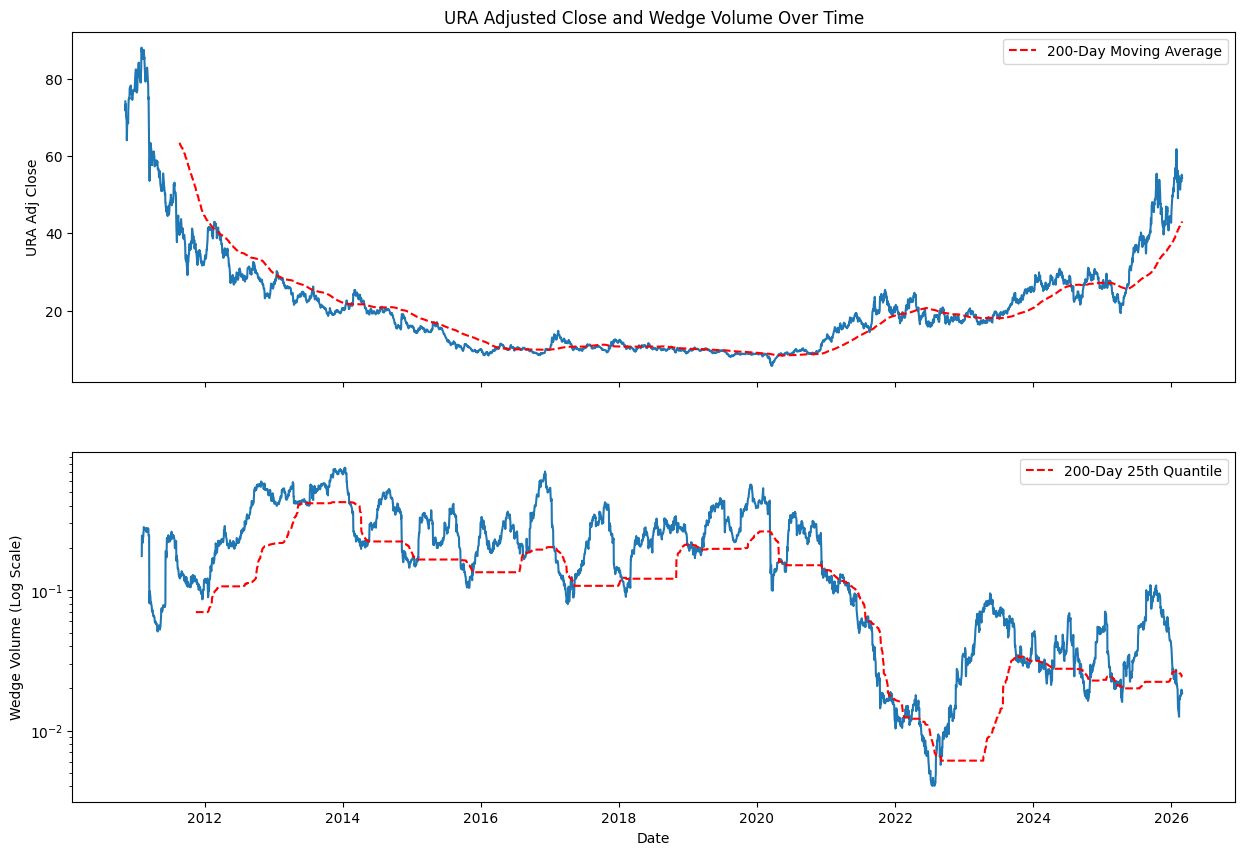

In [10]:
fig, axes= plt.subplots(nrows=2, ncols=1, figsize=(15, 10), sharex=True)

ura_data = dfs[0].copy()
ura_data.set_index('date', inplace=True)
ura_200_sma = ura_data['adj_close'].rolling(window=200).mean()
rolling_ma = ura_200_sma.loc[df.index] # Align with wedge volume index
ura_data = ura_data.loc[df.index] # Align with wedge volume index

axes[0].set_title('URA Adjusted Close and Wedge Volume Over Time')
axes[0].plot(ura_data['adj_close'])
axes[0].plot(rolling_ma, color='red', linestyle='--', label='200-Day Moving Average')
axes[0].set_ylabel('URA Adj Close')
axes[0].legend()

wedge_vol_200_sma = wedge_vol_series.rolling(window=200).quantile(0.15)
axes[1].plot(wedge_vol_series)
axes[1].plot(wedge_vol_200_sma, color='red', linestyle='--', label='200-Day 25th Quantile')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Wedge Volume (Log Scale)')
axes[1].set_yscale('log')
axes[1].legend()
plt.show()